# Visualizations

## Reddit

In [6]:
from Config.config import CONFIG
CONFIG = CONFIG("Reddit")

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

event_df = pd.read_csv("Documents/ExplainerOutputs/Reddit_Shapley4TGNNEvent.csv")
feat_df = pd.read_csv("Documents/ExplainerOutputs/Reddit_Shapley4TGNNFeature.csv")
tgnn_df = pd.read_csv("Documents/ExplainerOutputs/Reddit_TGNNExplainer.csv")
tempme_df = pd.read_csv("Documents/ExplainerOutputs/Reddit_TempME.csv")

results_list = [event_df, feat_df, tgnn_df, tempme_df]

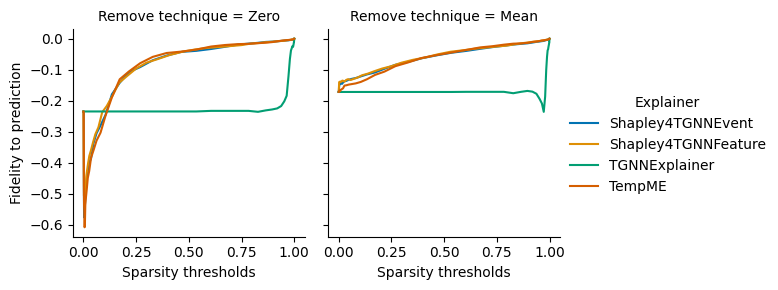

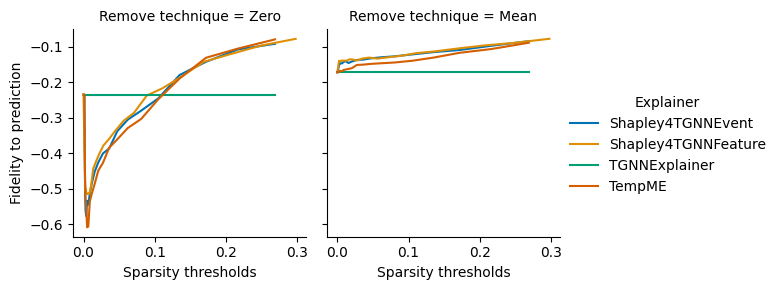

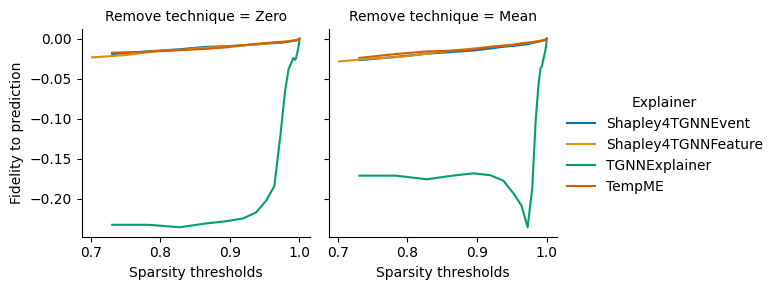

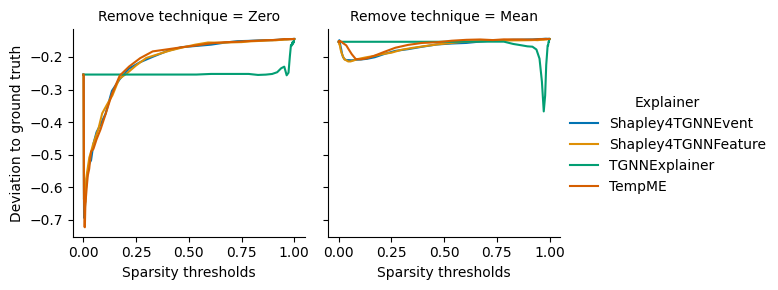

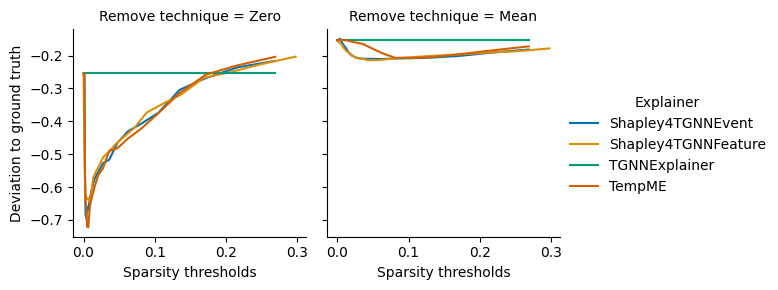

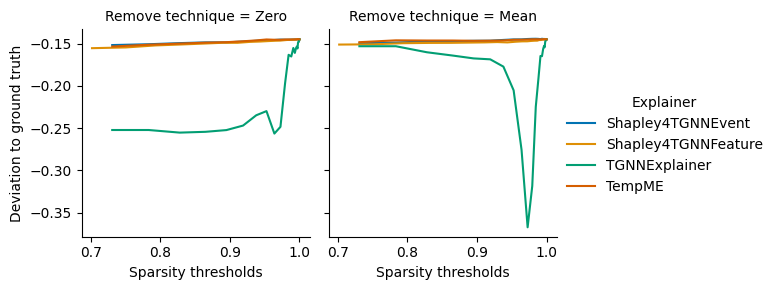

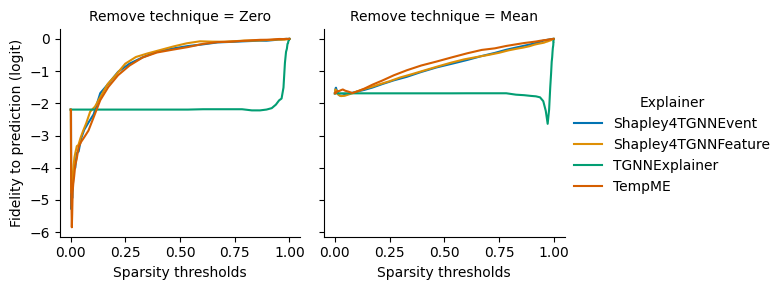

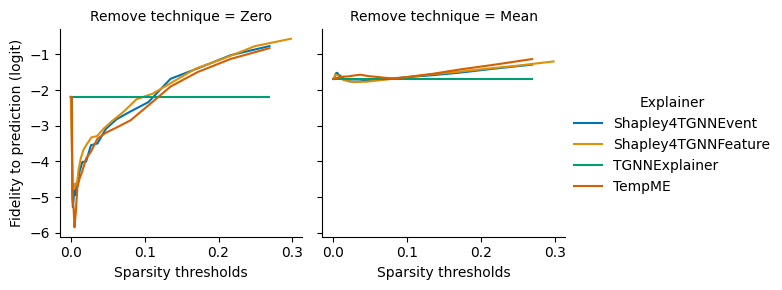

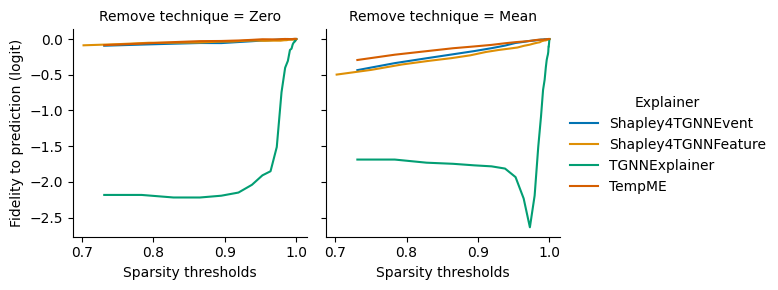

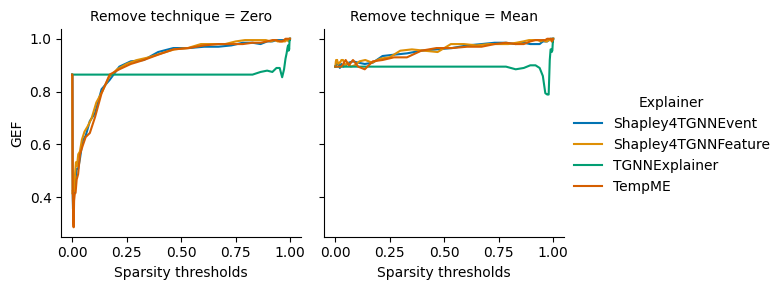

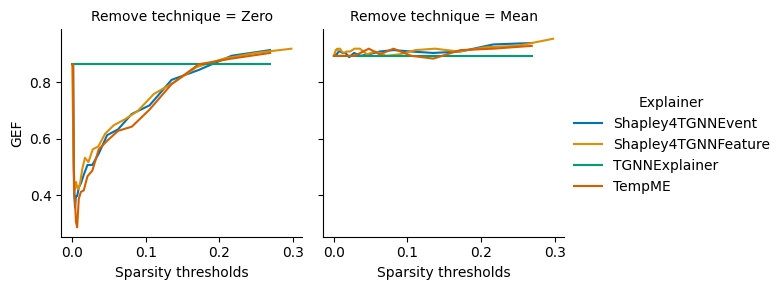

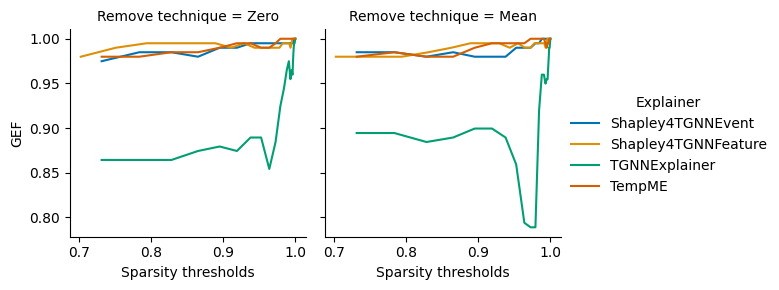

In [10]:
from Config.colors import PALLETTE2, PRIMARYCOLOR
import matplotlib.pyplot as plt

df = pd.concat(results_list)
df.head()

g = sns.FacetGrid(df, col="Remove technique", hue="Explainer", legend_out=True, palette=PALLETTE2)
g.map_dataframe(sns.lineplot, x="Sparsity thresholds", y="Fidelity to prediction")
g.add_legend()

import os
os.makedirs(f"Documents/Images/{CONFIG.data.dataset_name}", exist_ok=True)

g.savefig(f"Documents/Images/{CONFIG.data.dataset_name}/Fid_curve.png", bbox_inches='tight')

g = sns.FacetGrid(df[df["Sparsity thresholds"]<=0.3], col="Remove technique", hue="Explainer", legend_out=True, palette=PALLETTE2)
g.map_dataframe(sns.lineplot, x="Sparsity thresholds", y="Fidelity to prediction")
g.add_legend()
g.savefig(f"Documents/Images/{CONFIG.data.dataset_name}/Fid_curve_lower_part.png", bbox_inches='tight')

g = sns.FacetGrid(df[df["Sparsity thresholds"]>=0.7], col="Remove technique", hue="Explainer", legend_out=True, palette=PALLETTE2)
g.map_dataframe(sns.lineplot, x="Sparsity thresholds", y="Fidelity to prediction")
g.add_legend()
g.savefig(f"Documents/Images/{CONFIG.data.dataset_name}/Fid_curve_upper_part.png", bbox_inches='tight')


g = sns.FacetGrid(df, col="Remove technique", hue="Explainer", legend_out=True, palette=PALLETTE2)
g.map_dataframe(sns.lineplot, x="Sparsity thresholds", y="Deviation to ground truth")
g.add_legend()
g.savefig(f"Documents/Images/{CONFIG.data.dataset_name}/Deviation_curve.png", bbox_inches='tight')

g = sns.FacetGrid(df[df["Sparsity thresholds"]<=0.3], col="Remove technique", hue="Explainer", legend_out=True, palette=PALLETTE2)
g.map_dataframe(sns.lineplot, x="Sparsity thresholds", y="Deviation to ground truth")
g.add_legend()
g.savefig(f"Documents/Images/{CONFIG.data.dataset_name}/Deviation_curve_lower_part.png", bbox_inches='tight')

g = sns.FacetGrid(df[df["Sparsity thresholds"]>=0.7], col="Remove technique", hue="Explainer", legend_out=True, palette=PALLETTE2)
g.map_dataframe(sns.lineplot, x="Sparsity thresholds", y="Deviation to ground truth")
g.add_legend()
g.savefig(f"Documents/Images/{CONFIG.data.dataset_name}/Deviation_curve_upper_part.png", bbox_inches='tight')


g = sns.FacetGrid(df, col="Remove technique", hue="Explainer", legend_out=True, palette=PALLETTE2)
g.map_dataframe(sns.lineplot, x="Sparsity thresholds", y="Fidelity to prediction (logit)")
g.add_legend()
g.savefig(f"Documents/Images/{CONFIG.data.dataset_name}/Fid_logit_curve.png", bbox_inches='tight')

g = sns.FacetGrid(df[df["Sparsity thresholds"]<=0.3], col="Remove technique", hue="Explainer", legend_out=True, palette=PALLETTE2)
g.map_dataframe(sns.lineplot, x="Sparsity thresholds", y="Fidelity to prediction (logit)")
g.add_legend()
g.savefig(f"Documents/Images/{CONFIG.data.dataset_name}/Fid_logit_curve_lower_part.png", bbox_inches='tight')

g = sns.FacetGrid(df[df["Sparsity thresholds"]>=0.7], col="Remove technique", hue="Explainer", legend_out=True, palette=PALLETTE2)
g.map_dataframe(sns.lineplot, x="Sparsity thresholds", y="Fidelity to prediction (logit)")
g.add_legend()
g.savefig(f"Documents/Images/{CONFIG.data.dataset_name}/Fid_logit_curve_upper_part.png", bbox_inches='tight')

g = sns.FacetGrid(df, col="Remove technique", hue="Explainer", legend_out=True, palette=PALLETTE2)
g.map_dataframe(sns.lineplot, x="Sparsity thresholds", y="GEF")
g.add_legend()
g.savefig(f"Documents/Images/{CONFIG.data.dataset_name}/GEF_curve.png", bbox_inches='tight')

g = sns.FacetGrid(df[df["Sparsity thresholds"]<=0.3], col="Remove technique", hue="Explainer", legend_out=True, palette=PALLETTE2)
g.map_dataframe(sns.lineplot, x="Sparsity thresholds", y="GEF")
g.add_legend()
g.savefig(f"Documents/Images/{CONFIG.data.dataset_name}/GEF_curve_lower_part.png", bbox_inches='tight')

g = sns.FacetGrid(df[df["Sparsity thresholds"]>=0.7], col="Remove technique", hue="Explainer", legend_out=True, palette=PALLETTE2)
g.map_dataframe(sns.lineplot, x="Sparsity thresholds", y="GEF")
g.add_legend()
g.savefig(f"Documents/Images/{CONFIG.data.dataset_name}/GEF_curve_upper_part.png", bbox_inches='tight')

In [15]:
from Explainers.utils import calc_auc
from sklearn.metrics import auc
import numpy as np

auc_fid_log_zero = calc_auc(results_list, "Fidelity to prediction (logit)", "Zero")
auc_fid_log_mean = calc_auc(results_list, "Fidelity to prediction (logit)", "Mean")
auc_fid_zero = calc_auc(results_list, "Fidelity to prediction", "Zero")
auc_fid_mean = calc_auc(results_list, "Fidelity to prediction", "Mean")
auc_dev_zero = calc_auc(results_list, "Deviation to ground truth", "Zero")
auc_dev_mean = calc_auc(results_list, "Deviation to ground truth", "Mean")
auc_gef_zero = calc_auc(results_list, "GEF", "Zero")
auc_gef_mean = calc_auc(results_list, "GEF", "Mean", no_adjust=True)
auc_acc_zero = calc_auc(results_list, "Accuracy", "Zero", no_adjust=True)
auc_acc_mean = calc_auc(results_list, "Accuracy", "Mean", no_adjust=True)

print(f"AUC for Fidelity (logit) using Zero: {auc_fid_log_zero}")
print(f"AUC for Fidelity (logit) using Mean: {auc_fid_log_mean}")
print("")
print(f"AUC for Fidelity using Zero: {auc_fid_zero}")
print(f"AUC for Fidelity using Mean: {auc_fid_mean}")
print("")
print(f"AUC for Deviation using Zero: {auc_dev_zero}")
print(f"AUC for Deviation using Mean: {auc_dev_mean}")
print("")
print(f"AUC for GEF using Zero: {auc_gef_zero}")
print(f"AUC for GEF using Mean: {auc_gef_mean}")
print("")
print(f"AUC for Accuracy using Zero: {auc_acc_zero}")
print(f"AUC for Accuracy using Mean: {auc_acc_mean}")

content_zero = []
for expl in range(len(auc_fid_zero)):
    text = ""
    for metric in [auc_fid_zero, auc_fid_log_zero, auc_dev_zero, auc_gef_zero]: 
        # keep four decimal places also trailing zeros
        t = f"{metric[expl]:.4f}"
        ranking = np.sort(metric)
        if metric[expl] == ranking[-1]:  #Check if best
            t = "\\textbf{" + t + "}"
        elif metric[expl] == ranking[-2]:  #Check if second best
            t = "\\underline{" + t + "}"
        text += t + " & "
    text = text[:-3]  # remove last &
    content_zero.append(text)
    
content_mean = []
for expl in range(len(auc_fid_mean)):
    text = ""
    for metric in [auc_fid_mean, auc_fid_log_mean, auc_dev_mean, auc_gef_mean]: 
        # keep four decimal places also trailing zeros
        t = f"{metric[expl]:.4f}"
        ranking = np.sort(metric)
        if metric[expl] == ranking[-1]:  #Check if best
            t = "\\textbf{" + t + "}"
        elif metric[expl] == ranking[-2]:  #Check if second best
            t = "\\underline{" + t + "}"
        text += t + " & "
    text = text[:-3]  # remove last &
    content_mean.append(text)

    
text_zero=f"""
\\parbox[t]{{5mm}}{{\\multirow{{4}}{{*}}{{\\rotatebox[origin=c]{{90}}{{{CONFIG.data.dataset_name}}}}}}} & TGNN Explainer & {content_zero[2]} \\\\
& TempME & {content_zero[3]} \\\\
& Shapley (Event) & {content_zero[0]}\\\\
& Shapley (Feature) & {content_zero[1]}\\\\
"""

print(text_zero)

text_mean=f"""
\\parbox[t]{{5mm}}{{\\multirow{{4}}{{*}}{{\\rotatebox[origin=c]{{90}}{{{CONFIG.data.dataset_name}}}}}}} & TGNN Explainer & {content_mean[2]} \\\\
& TempME & {content_mean[3]} \\\\
& Shapley (Event) & {content_mean[0]} \\\\
& Shapley (Feature) & {content_mean[1]} \\\\
"""

print(text_mean)

AUC for Fidelity (logit) using Zero: [np.float64(5.13761111871081), np.float64(5.189140568011336), np.float64(3.7158930771743783), np.float64(5.1004901973260335)]
AUC for Fidelity (logit) using Mean: [np.float64(4.985248087314801), np.float64(4.986107851195408), np.float64(4.147021649530208), np.float64(5.113686233620785)]

AUC for Fidelity using Zero: [np.float64(0.5252556916038059), np.float64(0.5274076304062307), np.float64(0.3818717437005204), np.float64(0.5266099004403235)]
AUC for Fidelity using Mean: [np.float64(0.5496144782267334), np.float64(0.5514702942500539), np.float64(0.43797455550989073), np.float64(0.5472603538965184)]

AUC for Deviation using Zero: [np.float64(0.5085617810692563), np.float64(0.5094324324601872), np.float64(0.4717873922222875), np.float64(0.5102101145133707)]
AUC for Deviation using Mean: [np.float64(0.5542961814890692), np.float64(0.5545605961028918), np.float64(0.562365718893965), np.float64(0.5615387456310054)]

AUC for GEF using Zero: [np.float64(0.